In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [12]:
DROP_COLUMNS = ["PassengerId","Name","Ticket"]

In [13]:
def drop_cols(df: pd.DataFrame, cols: list[str])-> pd.DataFrame:
    """
    Drop specific cols from df
    """

    return df.drop(columns=cols)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


<h1>Check Data Types</h1>

In [15]:
df.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [16]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtypes : ":dtypes, "Num_Uniqu": n_uniq }).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes :,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqu,2,3,2,88,7,7,248,147,3


In [17]:
from ps import get_check_dtype
get_check_dtype(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqu,2,3,2,88,7,7,248,147,3


In [18]:
df.shape[0]

891

In [19]:
null = df.isnull().sum()
ratio = null / df.shape[0]
pd.DataFrame({"nulls_sum": null, "ratio ": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls_sum,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [20]:
cols = ['Survived', 'SibSp', 'Sex','Parch', 'Embarked' ]
df[cols] = df[cols].astype('category')
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,int64,category,float64,category,category,float64,str,category


In [21]:
df = df.dropna(subset=['Embarked'])

In [22]:
mean = df['Age'].mean()
print(mean)
print("=" * 40)
median_1 = df['Age'].median()
print(median_1)
df['Age'].fillna(median_1, inplace= True)
df.head()

29.64209269662921
28.0


C:\Users\Fahd\AppData\Local\Temp\ipykernel_10260\91719063.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_1, inplace= True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [23]:
null = df.isnull().sum()
ratio = null / df.shape[0]
pd.DataFrame({"nulls_sum": null, "ratio ": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls_sum,0.0,0.0,0.0,177.0000,0.0,0.0,0.0,687.000000,0.0
ratio,0.0,0.0,0.0,0.1991,0.0,0.0,0.0,0.772778,0.0


In [24]:
df.describe()

,Pclass,Age,Fare
count,889.000000,712.000000,889.000000
mean,2.311586,29.642093,32.096681
std,0.834700,14.492933,49.697504
min,1.000000,0.420000,0.000000
25%,2.000000,20.000000,7.895800
50%,3.000000,28.000000,14.454200
75%,3.000000,38.000000,31.000000
max,3.000000,80.000000,512.329200


In [25]:
num_cols = df.select_dtypes("number").columns
num_cols

Index(['Pclass', 'Age', 'Fare'], dtype='str')

In [26]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q1 + 1.5*IQR
    # print(lower_fence ,upper_fence)
    Lower_outliers = df[     df[col]<lower_fence   ][col].values
    upper_outliers = df[     df[col]>upper_fence   ][col].values
    print(Lower_outliers, upper_outliers)
    
    

[] []
[] [54.  58.  55.  66.  49.  65.  59.  71.  70.5 54.  51.  55.5 51.  61.
 56.  50.  58.  51.  59.  54.  62.  50.  52.  58.  63.  65.  50.  54.
 61.  60.  51.  50.  64.  52.  49.  65.  50.  48.  48.  56.  50.  63.
 58.  55.  71.  54.  54.  50.  50.  64.  62.  48.  62.  53.  54.  60.
 52.  49.  49.  61.  57.  80.  51.  48.  56.  58.  50.  70.  60.  60.
 52.  49.  48.  52.  50.  48.  70.  48.  51.  48.  57.  54.  49.  52.
 74.  51.  48.  56. ]
[] [ 71.2833  53.1     51.8625 263.     146.5208  82.1708  52.      76.7292
  61.9792  46.9     83.475   46.9     73.5     56.4958  47.1    263.
  61.175   63.3583  77.2875  52.     247.5208  73.5     77.2875  53.1
  79.2     66.6     61.3792  69.55    55.      56.4958  69.55    50.
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      52.5542
  79.2     86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85
  91.0792 151.55   247.5208 151.55   110.8833 108.9     56.9292  83.1583
 262.375  164.8667 134.5     69.55   135.6333  5

In [27]:
df.describe()

,Pclass,Age,Fare
count,889.000000,712.000000,889.000000
mean,2.311586,29.642093,32.096681
std,0.834700,14.492933,49.697504
min,1.000000,0.420000,0.000000
25%,2.000000,20.000000,7.895800
50%,3.000000,28.000000,14.454200
75%,3.000000,38.000000,31.000000
max,3.000000,80.000000,512.329200


In [28]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


['Age', 'Fare']


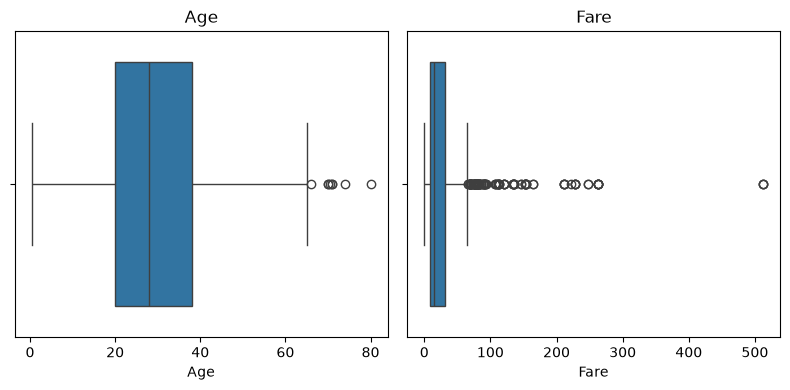

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = ["Age", "Fare"]
print(num_col)
plt.figure(figsize=(8, 4))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x=df[col], orient="h")
    plt.title(col)
plt.tight_layout()
plt.show()

In [31]:
num_col = ["Age", "Fare"]
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q1 + 1.5*IQR
    # print(lower_fence ,upper_fence)
    Lower_outliers = df[     df[col]<lower_fence   ][col].values
    upper_outliers = df[     df[col]>upper_fence   ][col].values

    df[col]= df[col].replace(Lower_outliers,lower_fence, inplace=True )
    df[col]= df[col].replace(upper_outliers,upper_fence, inplace= True)
    
    

C:\Users\Fahd\AppData\Local\Temp\ipykernel_10260\864933121.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col]= df[col].replace(Lower_outliers,lower_fence, inplace=True )
C:\Users\Fahd\AppData\Local\Temp\ipykernel_10260\864933121.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through c

In [32]:
df.duplicated().sum()

np.int64(120)

In [33]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = "first"):
    count = df.duplicated()
    return (df.drop_duplicates(subset=subset_cols, keep=keep_strategy).reset_index(drop = True))


In [34]:
remove_duplicated_records(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,42.5521,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,42.5521,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
764,0,3,female,39.0,0,5,29.1250,NaN,Q
765,1,1,female,19.0,0,0,30.0000,B42,S
766,0,3,female,NaN,1,2,23.4500,NaN,S
767,1,1,male,26.0,0,0,30.0000,C148,C


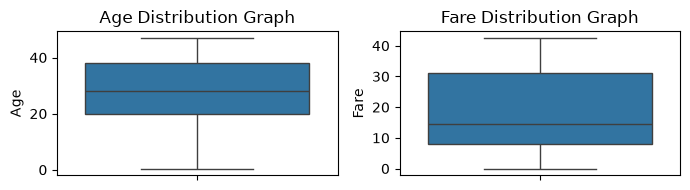

In [35]:
plt.figure(figsize=(7, 2))

for i, col in enumerate(num_col):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col])
    plt.title(f"{col} Distribution Graph")
    plt.tight_layout()
plt.show()

In [36]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

In [37]:
cat_cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
df[cat_cols] = df[cat_cols].astype("category")

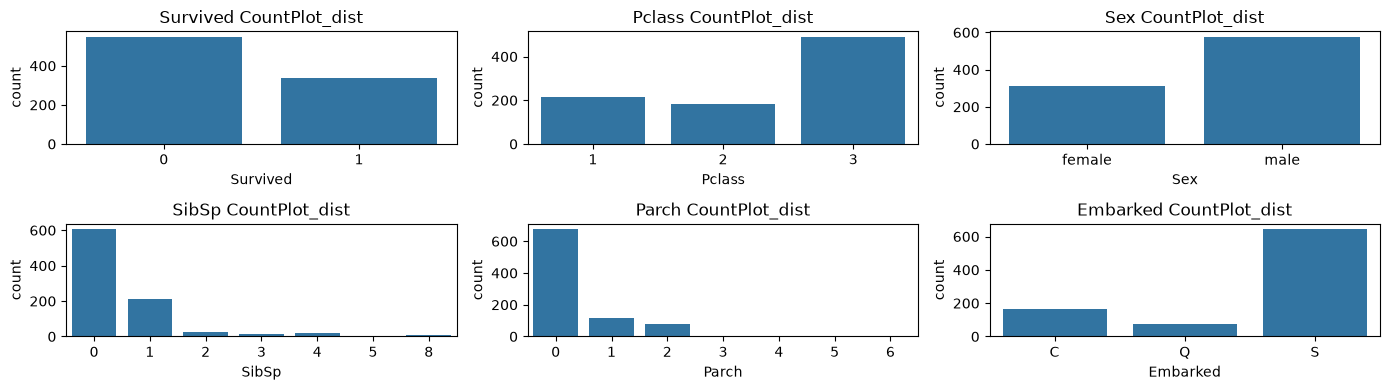

In [38]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} CountPlot_dist")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

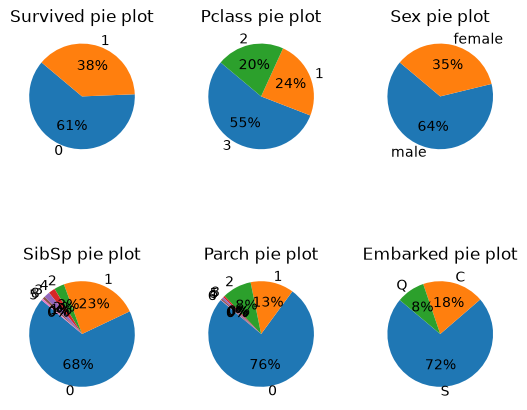

In [39]:
cat_cols
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count,labels=categories,startangle=140,autopct='%1.1d%%')
    plt.title(f"{col} pie plot")
plt.subplots_adjust(hspace=0.8 , wspace=0.3)
plt.show

In [40]:
unique = df[col].value_counts()
count = unique.values
count

array([644, 168,  77])

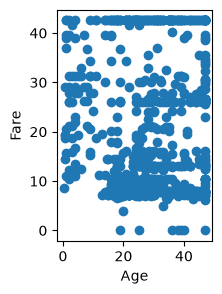

In [41]:
plt.figure(figsize=(2,3))
plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

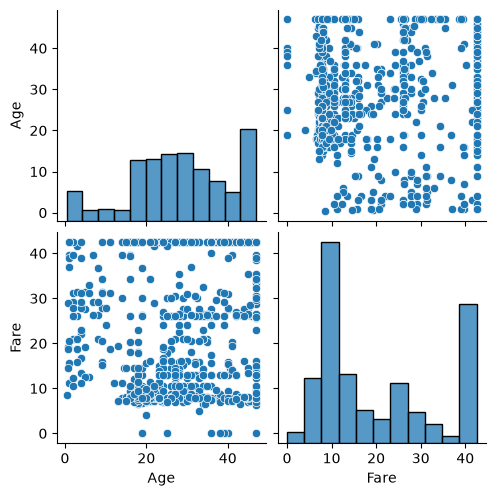

In [42]:
sns.pairplot(df)

In [43]:
corr_1 = df.corr(numeric_only=True)
corr_1

,Age,Fare
Age,1.000000,0.108721
Fare,0.108721,1.000000


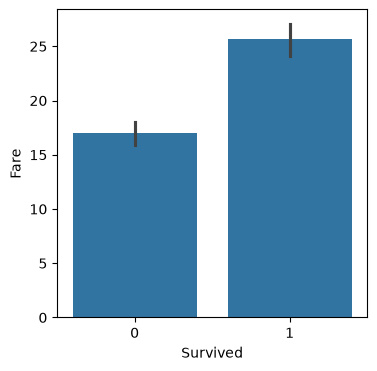

In [44]:
plt.figure(figsize=(4,4))
sns.barplot(x = "Survived", y = "Fare", data = df)
plt.show()

In [45]:
df


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,42.5521,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,42.5521,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [46]:
x = df.drop("Survived", axis = 1)
x = df.drop("Cabin", axis = 1)
y= df[["Survived"]]

In [47]:
x.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,42.5521,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,42.5521,S
4,0,3,male,35.0,0,0,8.0500,S


In [48]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.transform(x[num_cols])
x[num_cols]

,Pclass,Age,Fare
0,1.0,0.463289,0.170379
1,0.0,0.806784,1.000000
2,1.0,0.549163,0.186242
3,0.0,0.742379,1.000000
4,1.0,0.742379,0.189180
...,...,...,...
886,0.5,0.570631,0.305508
887,0.0,0.398884,0.705018
888,1.0,NaN,0.551089
889,0.0,0.549163,0.705018


In [50]:
x.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1.0,male,0.463289,1,0,0.170379,S
1,1,0.0,female,0.806784,1,0,1.000000,C
2,1,1.0,female,0.549163,0,0,0.186242,S
3,1,0.0,female,0.742379,1,0,1.000000,S
4,0,1.0,male,0.742379,0,0,0.189180,S


In [51]:
str_cols = ['Sex','Embarked']

In [52]:
pip install category-encoders

Note: you may need to restart the kernel to use updated packages.


In [53]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols = str_cols, drop_invariant= True)
x = encoder.fit_transform(x)

In [54]:
x.head()

,Survived,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,0,1.0,1,0,0.463289,1,0,0.170379,1,0,0
1,1,0.0,0,1,0.806784,1,0,1.000000,0,1,0
2,1,1.0,0,1,0.549163,0,0,0.186242,1,0,0
3,1,0.0,0,1,0.742379,1,0,1.000000,1,0,0
4,0,1.0,1,0,0.742379,0,0,0.189180,1,0,0


In [55]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [56]:
import plotly.express as px
import plotly.graph_objects as go

In [59]:
fig = px.pie(df, names='Survived',
            title = "<b> survived disribution </b>",
            color_discrete_sequence=px.colors.qualitative.Pastel,
            hole=0.7)
fig.show()


In [58]:
pip install "nbformat>=4.2.0"

Note: you may need to restart the kernel to use updated packages.


In [61]:
px.histogram(df, x = 'Survived', color='Sex', title='<b> survived disribution based on gender </b>', barmode='group')

In [65]:
fig = px.scatter(df, x = 'Age', y = 'Fare', title="scatter plot", opacity= 0.5)
fig.show()